Task 2: Credit Risk Prediction
Objective:
Predict whether a loan applicant is likely to default on a loan.
Dataset:
Loan Prediction Dataset (available on Kaggle)
Instructions:
● Handle missing data appropriately.
● Visualize key features such as loan amount, education, and income.
● Train a classification model like Logistic Regression or Decision Tree.
● Evaluate the model using accuracy and a confusion matrix.

Skills:
● Data cleaning and handling missing values
● Exploratory Data Analysis (EDA)
● Binary classification using machine learning
● Model evaluation using confusion matrix and accuracy


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score


In [3]:
df = pd.read_csv('loan_prediction_dataset.csv')

In [4]:
df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


In [7]:
df.shape

(2000, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                2000 non-null   int64
 1   Income             2000 non-null   int64
 2   Credit_Score       2000 non-null   int64
 3   Loan_Amount        2000 non-null   int64
 4   Loan_Term          2000 non-null   int64
 5   Employment_Status  2000 non-null   str  
 6   Loan_Approved      2000 non-null   int64
dtypes: int64(6), str(1)
memory usage: 109.5 KB


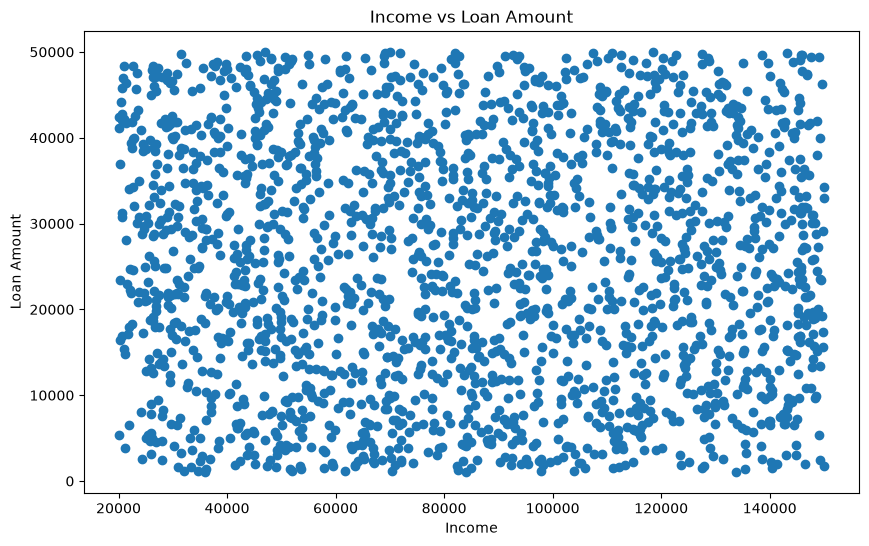

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Income'], df['Loan_Amount'])
plt.xlabel('Income')
plt.ylabel('Loan Amount')
plt.title('Income vs Loan Amount')
plt.show()

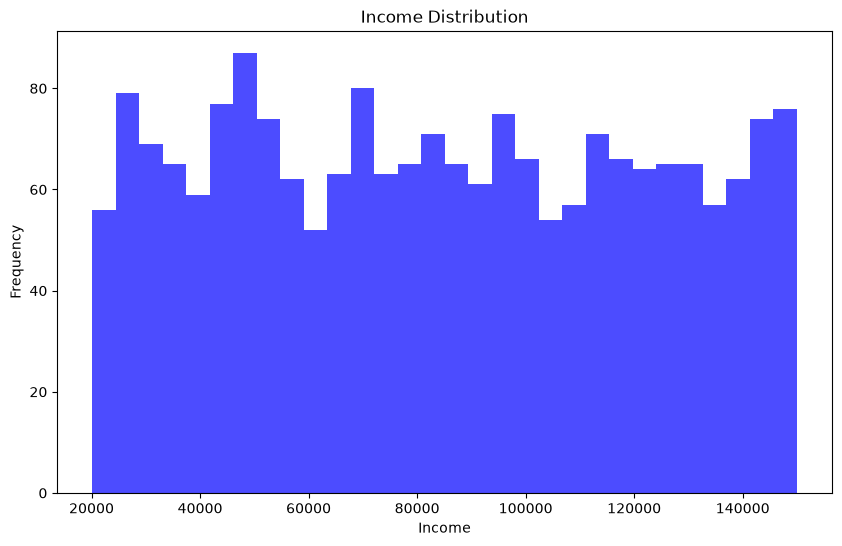

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(df['Income'], bins=30, alpha=0.7, color='blue')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.title('Income Distribution')
plt.show()

<Axes: xlabel='Loan_Approved', ylabel='count'>

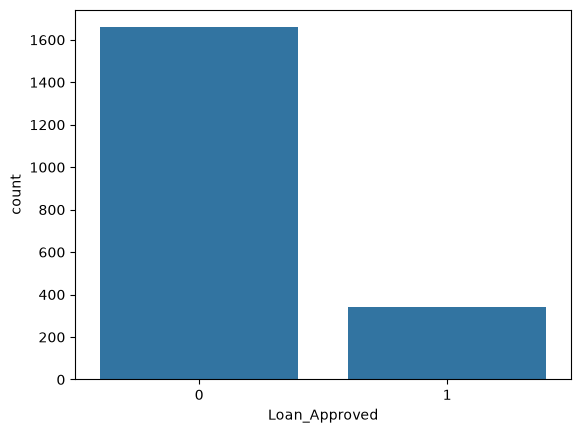

In [12]:
sns.countplot(x='Loan_Approved', data=df)

<Axes: xlabel='Loan_Approved', ylabel='Credit_Score'>

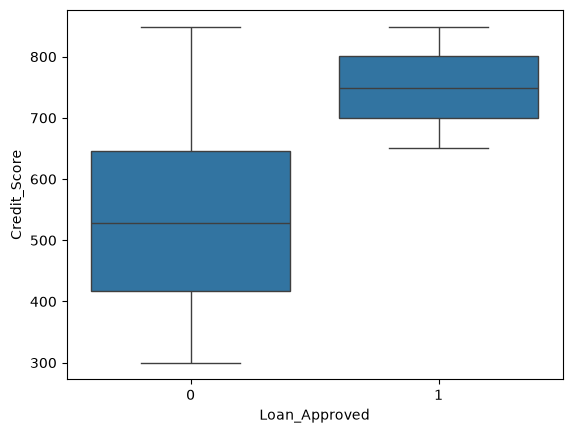

In [14]:
sns.boxplot(
    x='Loan_Approved',
    y='Credit_Score',
    data=df
)

<Axes: xlabel='Loan_Approved', ylabel='Income'>

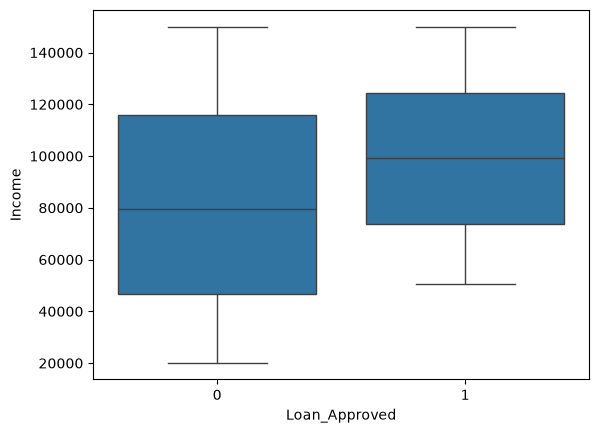

In [15]:
sns.boxplot(
    x='Loan_Approved',
    y='Income',
    data=df
)

<Axes: >

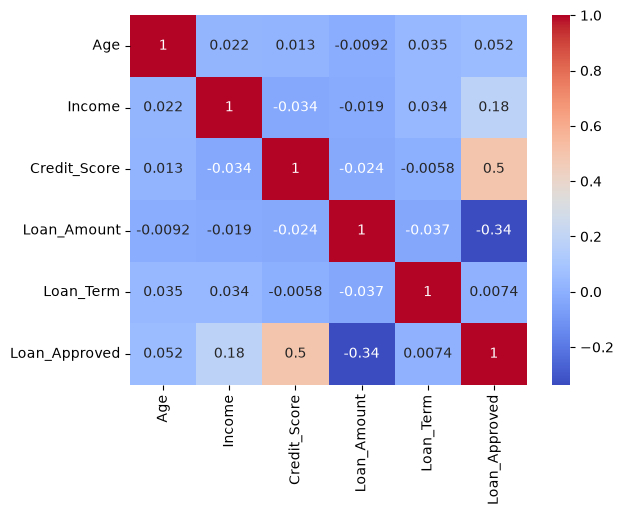

In [17]:
numeric_cols = [
    'Age',
    'Income',
    'Credit_Score',
    'Loan_Amount',
    'Loan_Term',
    'Loan_Approved'
]

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

In [25]:
df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed
0,56,81788,334,15022,48,0,1,0,0
1,69,102879,781,21013,24,1,0,1,0
2,46,58827,779,39687,60,0,0,1,0
3,32,127188,364,16886,24,0,0,0,1
4,60,25655,307,26256,36,0,0,0,1


In [24]:
df = pd.get_dummies(
    df,
    columns=['Employment_Status'],
    dtype=int
)

In [ ]:
y = df['Loan_Approved']

X = df.drop('Loan_Approved', axis=1)



In [28]:
X.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed
0,56,81788,334,15022,48,1,0,0
1,69,102879,781,21013,24,0,1,0
2,46,58827,779,39687,60,0,1,0
3,32,127188,364,16886,24,0,0,1
4,60,25655,307,26256,36,0,0,1


In [46]:
model = LogisticRegression()


In [47]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
model.fit(x_train, y_train)

/home/waleedqamar/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [49]:
y_predict  = model.predict(x_test)

In [50]:
mse = mean_squared_error(y_test, y_predict)

In [51]:
mse

0.1775

In [52]:
r2 = r2_score(y_test, y_predict)

In [53]:
r2

-0.13075330466634827

In [54]:
print(y_predict[:10])

[0 0 0 0 0 0 0 0 0 0]


In [55]:
y_pred_class = (y_predict >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_class))
print("Precision:", precision_score(y_test, y_pred_class))
print("Recall   :", recall_score(y_test, y_pred_class))
print("F1 Score :", f1_score(y_test, y_pred_class))

Accuracy : 0.8225
Precision: 0.5777777777777777
Recall   : 0.3333333333333333
F1 Score : 0.42276422764227645
